# GAN（生成对抗网络）实现 - CIFAR-10

## 生成对抗网络（GAN）原理

生成对抗网络（Generative Adversarial Networks，简称GAN）是一种深度学习模型架构，由Ian Goodfellow在2014年提出。GAN由两个神经网络组成：生成器（Generator）和判别器（Discriminator），这两个网络通过对抗学习的方式进行训练。

### GAN的基本思想

GAN的核心思想可以类比为"造假者"与"鉴定者"之间的博弈：
- **生成器（Generator）**：尝试生成逼真的假数据，目标是欺骗判别器。
- **判别器（Discriminator）**：尝试区分真实数据和生成器生成的假数据。

这种对抗过程通过不断迭代进行，最终使生成器能够生成高质量的、接近真实数据分布的样本。

### GAN的数学表达

GAN的训练过程可以表示为一个极小极大博弈（minimax game）。假设：
- $G$: 生成器网络
- $D$: 判别器网络
- $p_{data}(x)$: 真实数据的分布
- $p_z(z)$: 随机噪声的分布（通常是均匀分布或高斯分布）
- $G(z)$: 生成器将随机噪声映射为假数据
- $D(x)$: 判别器输出数据为真实的概率（介于0和1之间）

### GAN的目标函数

GAN的训练目标可以表示为以下极小极大问题：

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$

这个公式可以理解为：
- 判别器$D$试图最大化这个函数，即最大化$\log D(x)$（真实数据被判断为真的概率）和$\log(1 - D(G(z)))$（生成数据被判断为假的概率）
- 生成器$G$试图最小化这个函数，即最小化$\log(1 - D(G(z)))$，即欺骗判别器，使其将生成数据判断为真

在实际训练中，为了避免梯度消失问题，生成器通常优化不同的目标函数：

$$\max_G \mathbb{E}_{z \sim p_z(z)}[\log D(G(z))]$$

这相当于生成器最大化判别器将其生成内容判断为真实的概率。

### 训练过程

GAN的训练通常交替进行：
1. 固定生成器$G$，训练判别器$D$几个批次
2. 固定判别器$D$，训练生成器$G$一个批次
3. 重复以上步骤直到收敛
```

实际训练GAN常常面临以下挑战：
- 模式崩溃（Mode collapse）：生成器只生成有限几种样本
- 训练不稳定：判别器和生成器的平衡难以保持
- 收敛困难：GAN可能永远不会达到纳什均衡
```

本实现使用CIFAR-10数据集，采用卷积神经网络构建生成器和判别器，通过多轮训练实现逼真图像的生成。

## 环境设置与超参数

In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

MODEL_SAVE_PATH = "../model/gan"
RESULT_SAVE_PATH = "../result/gan"

Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)
Path(RESULT_SAVE_PATH).mkdir(parents=True, exist_ok=True)

Using device: mps


### 超参数设置

GAN训练涉及多个关键超参数，这些参数会影响模型训练的稳定性和生成结果的质量：

- `batch_size`: 每批训练的样本数量，较大的批量有助于稳定训练
- `image_size`: 图像尺寸，CIFAR-10为32x32
- `nc`: 图像通道数，彩色图像为3通道(RGB)
- `nz`: 潜在向量(latent vector)的大小，用于生成器的输入
- `ngf`, `ndf`: 生成器和判别器中的特征图(feature maps)大小
- `num_epochs`: 训练的总轮数
- `lr`: 学习率，通常GAN使用较小的学习率
- `beta1`: Adam优化器的beta1参数，控制一阶矩估计的衰减率

这些超参数需要仔细调整以避免训练不稳定、模式崩溃等常见GAN问题。

In [ ]:
batch_size = 256
image_size = 32
nc = 3  # 训练图像的通道数 (RGB)
nz = 100  # 潜在向量z的大小
ngf = 64  # 生成器中特征图的大小
ndf = 64  # 判别器中特征图的大小
num_epochs = 100
lr = 0.0002
beta1 = 0.5

## 数据加载与预处理

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

### 模型权重初始化

权重初始化对GAN的训练非常重要，可以帮助网络更快收敛和避免梯度消失/爆炸问题。常用的初始化方法是正态分布初始化，特别是对卷积层和批归一化层。

以下函数`weights_init`实现了自定义权重初始化，对卷积层使用均值为0、标准差为0.02的正态分布，对批归一化层的权重使用均值为1、标准差为0.02的正态分布，偏置则初始化为0。

这种初始化策略常用于GAN训练，有助于模型在早期阶段生成更多样化的输出，从而避免模式崩溃。

In [ ]:
def weights_init(m):
    """
    Custom weight initialization function

    Args:
        m: model layer

    For Conv layers: initialize weights with normal distribution (mean=0, std=0.02)
    For BatchNorm layers: weights with normal(mean=1, std=0.02), bias=0

    卷积层使用均值为0、标准差为0.02的正态分布初始化
    批归一化层权重使用均值为1、标准差为0.02的正态分布初始化，偏置初始化为0
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## 生成器和判别器网络

GAN包含两个主要组件：生成器和判别器，它们是相互对立、共同训练的两个神经网络。

### 生成器网络

生成器的任务是将随机噪声转换为逼真的图像。这个实现使用了转置卷积（也称为反卷积）层，逐步将低维潜在向量扩展为高维图像。

网络结构遵循DCGAN（Deep Convolutional GAN）的设计思路，包含以下关键特点：
- 使用转置卷积而非上采样+卷积，有助于学习上采样过程
- 每层转置卷积后使用批归一化稳定训练
- 除最后一层外使用ReLU激活函数
- 最后一层使用Tanh激活函数将输出约束在[-1,1]范围

In [ ]:
class Generator(nn.Module):
    """
    生成器网络类
    
    将随机噪声向量转换为32x32x3的图像
    使用转置卷积层逐步上采样
    """
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 4 x 4
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 8 x 8
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 16 x 16
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 32 x 32
        )

    def forward(self, input):
        """
        前向传播函数
        
        Args:
            input: 潜在向量 z，形状为 [batch_size, nz, 1, 1]
            
        Returns:
            生成的图像，形状为 [batch_size, nc, 32, 32]
        """
        return self.main(input)
    
netG = Generator().to(device)
netG.apply(weights_init)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

### 判别器网络

判别器的任务是区分真实图像和生成图像。它是一个传统的卷积神经网络，逐步将图像降维，最终输出一个概率值。

网络结构特点：
- 使用步长为2的卷积实现下采样
- 除第一层外使用批归一化层稳定训练
- 使用LeakyReLU激活函数，避免判别器中常见的"死亡ReLU"问题
- 最后一层使用Sigmoid激活函数输出概率值

In [ ]:
class Discriminator(nn.Module):
    """
    判别器网络类
    
    判断输入图像是真实的还是生成的
    输出单个概率值
    """
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 32 x 32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 16 x 16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        """
        前向传播函数
        
        Args:
            input: 输入图像，形状为 [batch_size, nc, 32, 32]
            
        Returns:
            判别器输出的概率值，形状为 [batch_size, 1, 1, 1]
        """
        return self.main(input)

netD = Discriminator().to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

## 模型初始化和优化器设置

在GAN训练中，优化器的选择和配置对训练的稳定性有显著影响。Adam优化器通常是GAN训练的首选，因为它结合了动量和RMSprop的优点，能够适应不同参数的学习率。

对于GAN，通常使用较小的学习率（如0.0002），并调整beta1参数（通常为0.5而不是默认的0.9），以帮助稳定训练过程。这些设置可以减少训练中的振荡和模式崩溃问题。

下面的代码对生成器和判别器的实例配置了各自的优化器。同时，创建了一个固定的噪声向量用于评估训练过程中生成图像的质量和一致性。

In [ ]:
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

In [8]:
G_losses = []
D_losses = []
img_list = []

## 训练过程

GAN的训练过程是一个交替优化生成器和判别器的过程，目标是达到纳什均衡，即生成器生成的图像与真实图像分布相同，判别器无法区分真假图像（概率为0.5）。

训练主要包含以下步骤：

1. **训练判别器**:
   - 使用真实图像训练判别器，目标是最大化真实图像的输出概率
   - 使用生成器生成的假图像训练判别器，目标是最小化假图像的输出概率
   - 结合两部分损失，更新判别器参数

2. **训练生成器**:
   - 生成假图像并通过判别器
   - 目标是最大化判别器对假图像的输出概率（即欺骗判别器）
   - 更新生成器参数

3. **监控和保存**:
   - 保存训练过程中的损失值
   - 定期保存生成的图像样本
   - 保存最佳模型和最终模型

训练过程中使用进度条显示每个批次的损失值和其他指标，帮助监控训练进展。

In [ ]:
from tqdm import tqdm

best_G_loss = float('inf')
best_epoch = 0

for epoch in range(num_epochs):
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch+1}/{num_epochs}")

    epoch_G_loss = 0
    epoch_D_loss = 0
    num_batches = 0

    for i, data in pbar:
        ############################
        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        # Train with real batch
        netD.zero_grad()
        real_cpu = data[0].to(device)
        batch_size = real_cpu.size(0)
        label = torch.full((batch_size,), 1, dtype=torch.float, device=device)

        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Train with fake batch
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0)

        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update Generator: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(1)  # Fake labels are real for generator cost

        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()

        optimizerG.step()

        # Update tqdm progress bar with current loss values
        pbar.set_postfix({
            'Loss_D': f'{errD.item():.4f}',
            'Loss_G': f'{errG.item():.4f}',
            'D(x)': f'{D_x:.4f}',
            'D(G(z))': f'{D_G_z1:.4f}/{D_G_z2:.4f}'
        })

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Accumulate epoch losses
        epoch_G_loss += errG.item()
        epoch_D_loss += errD.item()
        num_batches += 1

        # Generate and save images at checkpoints
        if (epoch == 0 and i == 0) or ((epoch+1) % 5 == 0 and i == 0):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_grid = torchvision.utils.make_grid(fake, padding=2, normalize=True)
            img_list.append(img_grid)

            # Save the generated images
            plt.figure(figsize=(8, 8))
            plt.axis("off")
            plt.title(f"Generated Images at Epoch {epoch+1}")
            plt.imshow(np.transpose(img_grid.numpy(), (1, 2, 0)))
            plt.savefig(f"{RESULT_SAVE_PATH}/generated_images_epoch_{epoch+1}.png")
            plt.close()

    # Calculate average epoch losses
    avg_G_loss = epoch_G_loss / num_batches
    avg_D_loss = epoch_D_loss / num_batches
    print(f"\nEpoch {epoch+1}/{num_epochs} - Avg G_loss: {avg_G_loss:.4f}, Avg D_loss: {avg_D_loss:.4f}")

    # Save models every 5 epochs
    if (epoch+1) % 5 == 0:
        torch.save(netG.state_dict(), f"{MODEL_SAVE_PATH}/generator_epoch_{epoch+1}.pth")
        torch.save(netD.state_dict(), f"{MODEL_SAVE_PATH}/discriminator_epoch_{epoch+1}.pth")

        # Save loss plot at this checkpoint
        plt.figure(figsize=(10, 5))
        plt.title("Generator and Discriminator Loss During Training")
        plt.plot(G_losses, label="G")
        plt.plot(D_losses, label="D")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"{RESULT_SAVE_PATH}/loss_plot_epoch_{epoch+1}.png")
        plt.close()

    # Save the best model based on generator loss
    if avg_G_loss < best_G_loss:
        best_G_loss = avg_G_loss
        best_epoch = epoch + 1
        torch.save(netG.state_dict(), f"{MODEL_SAVE_PATH}/generator_best.pth")
        torch.save(netD.state_dict(), f"{MODEL_SAVE_PATH}/discriminator_best.pth")
        print(f"New best model saved at epoch {best_epoch} with G_loss: {best_G_loss:.4f}")

# Save the final model
torch.save(netG.state_dict(), f"{MODEL_SAVE_PATH}/generator_final.pth")
torch.save(netD.state_dict(), f"{MODEL_SAVE_PATH}/discriminator_final.pth")

print(f"Training complete. Best model was from epoch {best_epoch} with G_loss: {best_G_loss:.4f}")

Epoch 1/100: 100%|██████████| 196/196 [00:26<00:00,  7.48it/s, Loss_D=0.2703, Loss_G=5.5823, D(x)=0.8711, D(G(z))=0.0969/0.0050]


Epoch 1/100 - Avg G_loss: 5.2678, Avg D_loss: 0.3490
New best model saved at epoch 1 with G_loss: 5.2678



Epoch 2/100: 100%|██████████| 196/196 [00:25<00:00,  7.54it/s, Loss_D=0.4462, Loss_G=3.9250, D(x)=0.8131, D(G(z))=0.1706/0.0278]


Epoch 2/100 - Avg G_loss: 4.4444, Avg D_loss: 0.4806
New best model saved at epoch 2 with G_loss: 4.4444



Epoch 3/100: 100%|██████████| 196/196 [00:30<00:00,  6.34it/s, Loss_D=0.2924, Loss_G=3.5622, D(x)=0.8908, D(G(z))=0.1448/0.0437]

...


Epoch 98/100 - Avg G_loss: 2.2905, Avg D_loss: 0.5416



Epoch 99/100: 100%|██████████| 196/196 [00:27<00:00,  7.23it/s, Loss_D=0.4073, Loss_G=2.4229, D(x)=0.7879, D(G(z))=0.1343/0.1242]


Epoch 99/100 - Avg G_loss: 2.3198, Avg D_loss: 0.5588



Epoch 100/100: 100%|██████████| 196/196 [00:22<00:00,  8.72it/s, Loss_D=0.3509, Loss_G=3.3478, D(x)=0.8351, D(G(z))=0.1370/0.0541]


Epoch 100/100 - Avg G_loss: 2.3965, Avg D_loss: 0.7591
Training complete. Best model was from epoch 46 with G_loss: 1.7455


> 每5个epoch保存一次模型、损失曲线和生成图片，始终保存当前生成器最优权重。

---

In [10]:
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"{RESULT_SAVE_PATH}/loss_plot_final.png")
plt.close()

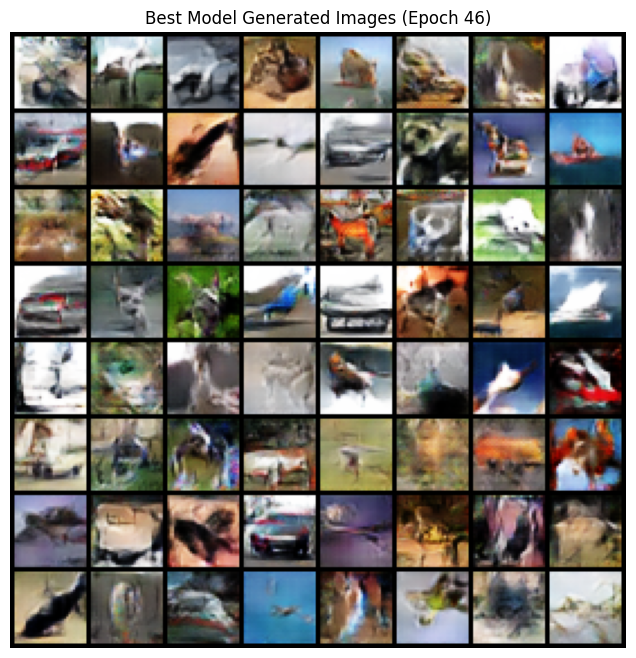

In [17]:
# Generate a final batch of images using the best model
netG.load_state_dict(torch.load(f"{MODEL_SAVE_PATH}/generator_best.pth"))
with torch.no_grad():
    best_generated = netG(fixed_noise).detach().cpu()
best_img_grid = torchvision.utils.make_grid(best_generated, padding=2, normalize=True)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title(f"Best Model Generated Images (Epoch {best_epoch})")
plt.imshow(np.transpose(best_img_grid.numpy(), (1, 2, 0)))
plt.savefig(f"{RESULT_SAVE_PATH}/best_generated_images.png")
plt.show()

In [ ]:
def show_images(imgs, num_images=25, size=(3, 32, 32)):
    """
    显示一批生成的图像
    
    Args:
        imgs: 图像张量，形状为 [batch_size, channels, height, width]
        num_images: 要显示的图像数量，默认为25
        size: 单个图像的大小，默认为(3, 32, 32)
    """
    plt.figure(figsize=(10, 10))

    for i in range(num_images):
        plt.subplot(5, 5, i+1)

        img = imgs[i].detach().cpu()

        img = img.permute(1, 2, 0)

        # Display the image
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f'{RESULT_SAVE_PATH}/generated_images.png')
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9709918..0.81257963].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8759243..0.74375117].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94615006..0.7697514].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9019694..0.9981474].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8465357..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9802161..0.8854852].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.93128425.

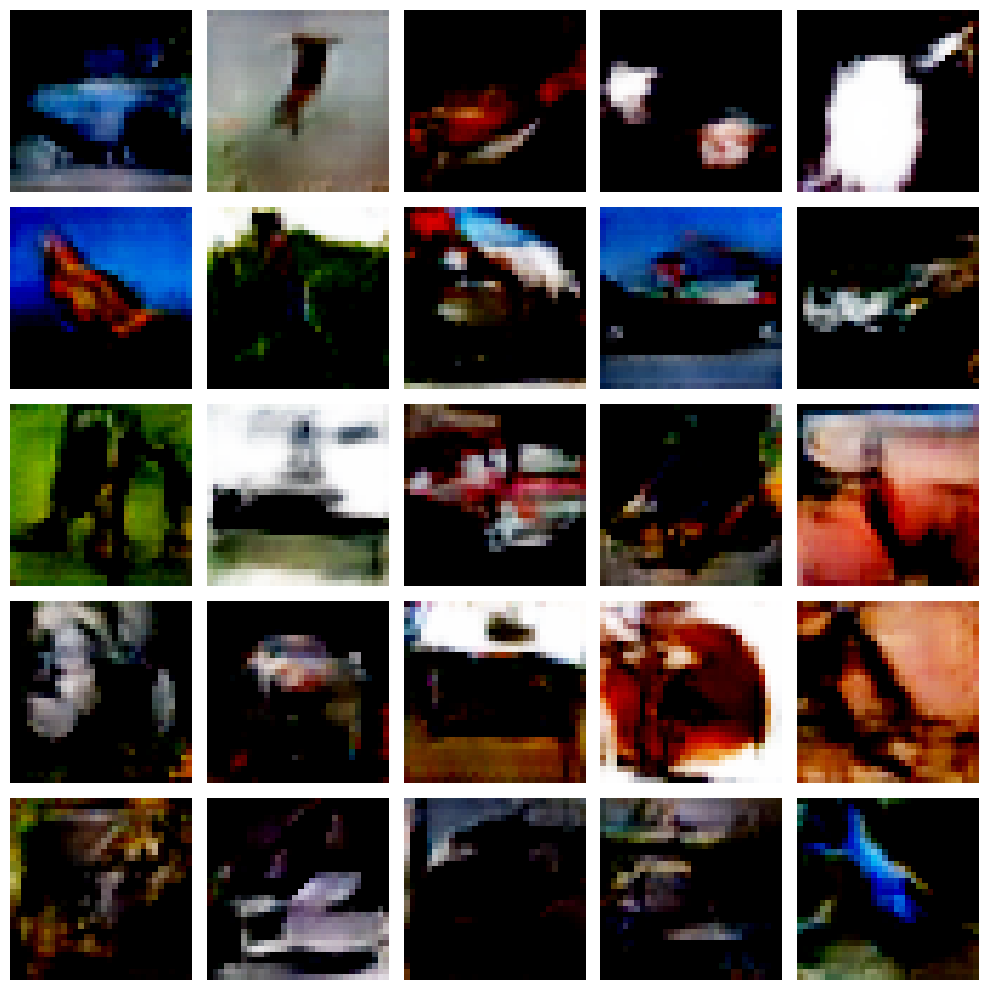

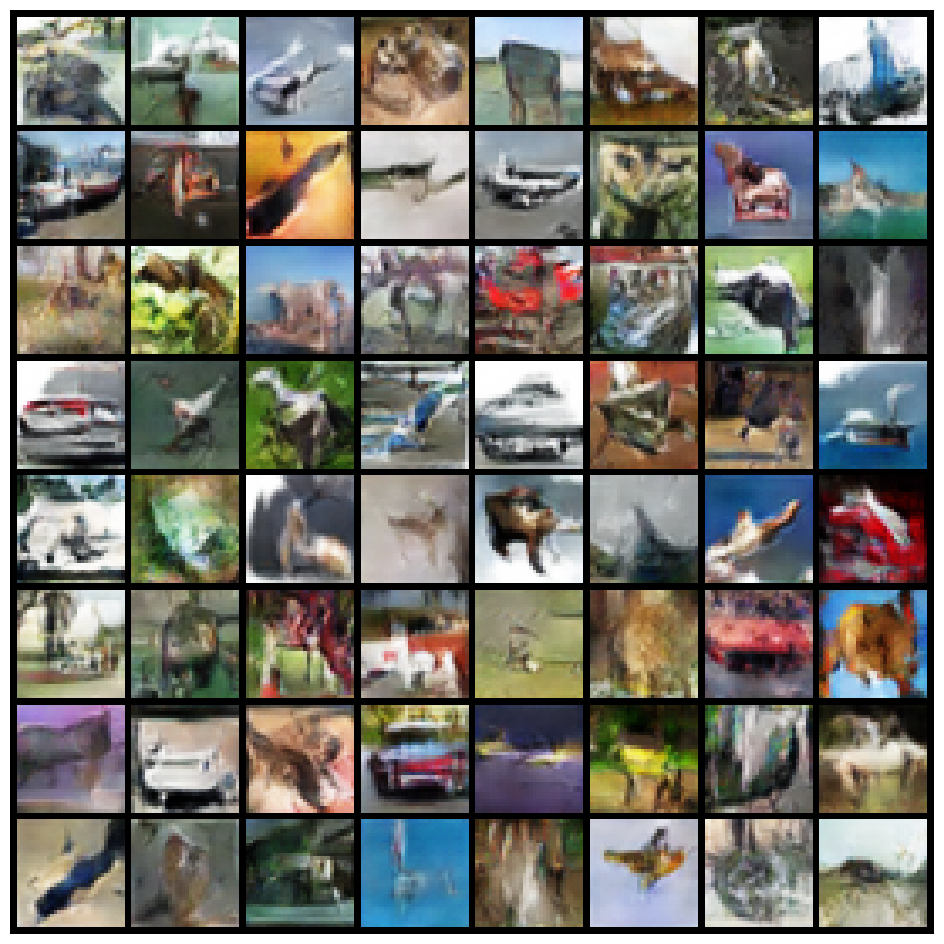

In [ ]:
with torch.no_grad():
    noise = torch.randn(25, nz, 1, 1, device=device)
    generated_images = netG(noise).detach().cpu()
    show_images(generated_images)

fig = plt.figure(figsize=(12, 12))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i, (1, 2, 0)), animated=True)] for i in img_list]
plt.savefig(f"{RESULT_SAVE_PATH}/training_progress.png")
plt.show()

## 训练结果和模型评估

在GAN训练的各个阶段，我们需要可视化生成的图像和跟踪损失变化，以评估训练进展和生成效果。

以下是几种评估GAN性能的方法：

1. **图像质量直观评估**：
   - 观察生成图像的清晰度、多样性和真实性
   - 比较不同训练阶段的生成效果

2. **损失曲线分析**：
   - 监控生成器和判别器损失的变化趋势
   - 理想情况下，两者应该保持相对平衡

3. **模型比较**：
   - 加载不同轮数的模型检查生成效果
   - 观察模型生成能力的进展

在本实现中，我们通过以下方式评估模型：
- 每5轮保存一次模型和生成的图像样本
- 保存训练过程中的损失曲线
- 保存最佳模型（基于生成器损失）
- 最终对比不同训练阶段的模型效果

通过这些评估，可以直观了解GAN训练的进展以及最终生成图像的质量。

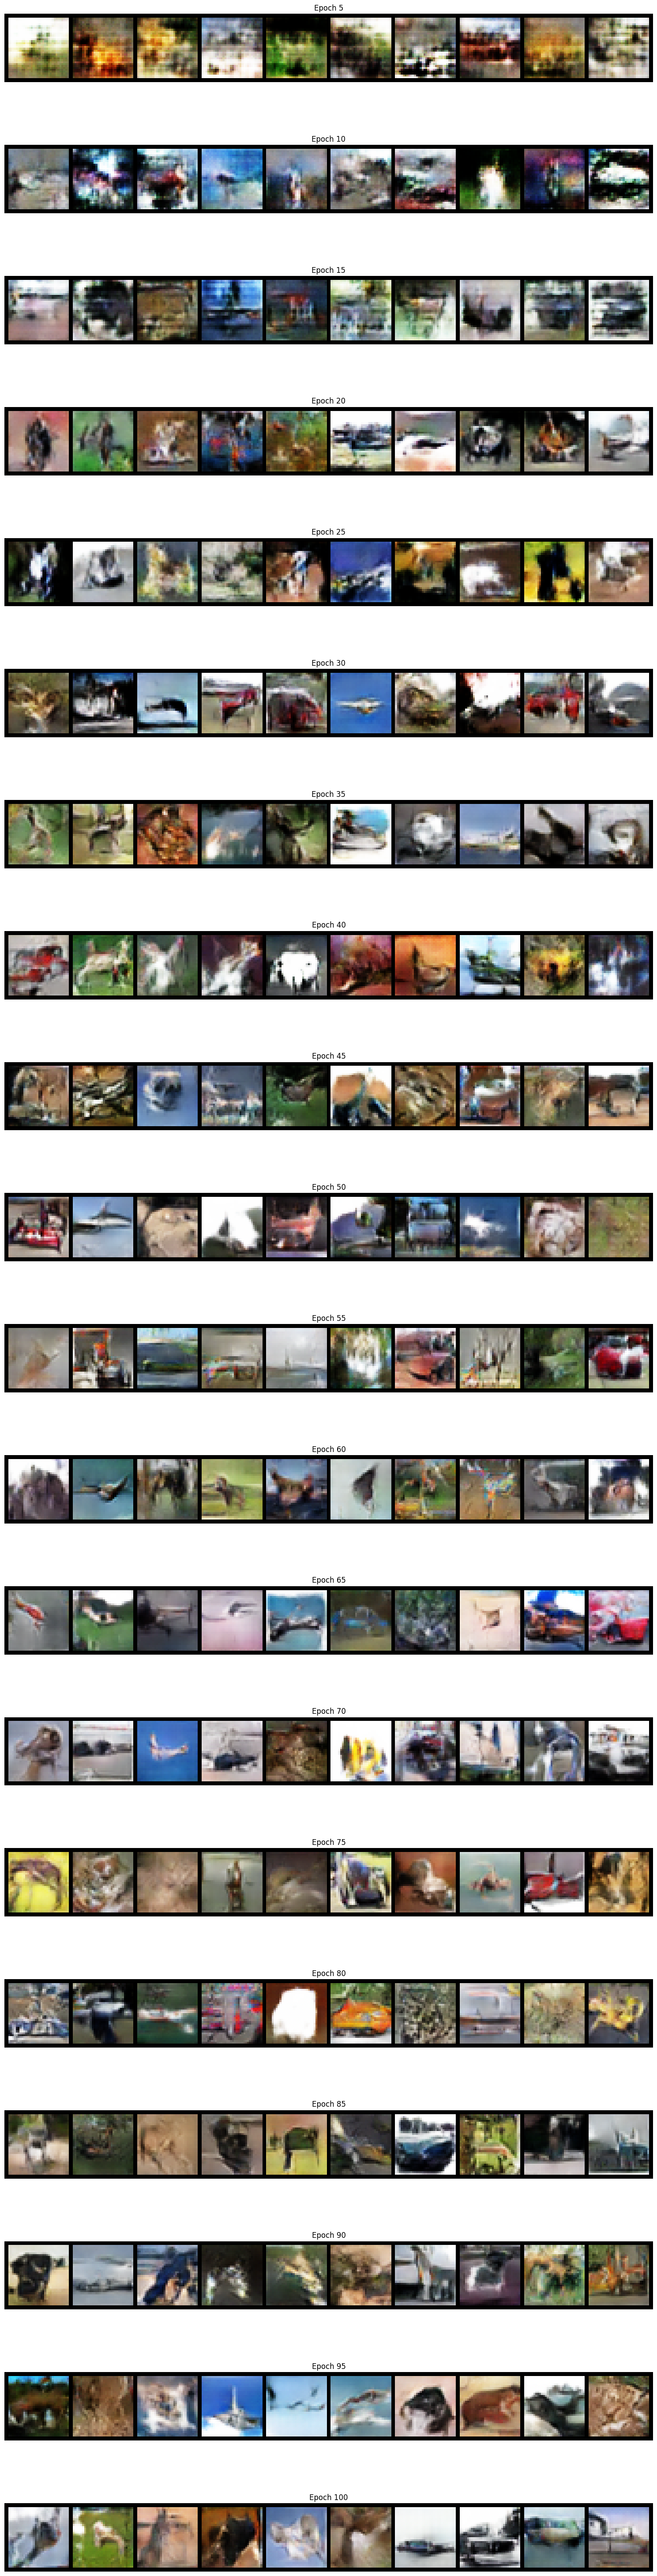

In [ ]:
import os

def compare_models_at_different_epochs(epochs=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]):
    """
    加载并比较不同训练阶段的模型生成效果
    
    Args:
        epochs: 要比较的训练轮数列表
    """
    plt.figure(figsize=(15, len(epochs) * 3))

    for i, epoch in enumerate(epochs):
        model_path = f"{MODEL_SAVE_PATH}/generator_epoch_{epoch}.pth"

        if not os.path.exists(model_path):
            print(f"Model for epoch {epoch} not found, skipping...")
            continue

        netG.load_state_dict(torch.load(model_path, map_location=device))
        netG.eval()

        with torch.no_grad():
            noise = torch.randn(10, nz, 1, 1, device=device)
            fake_images = netG(noise).detach().cpu()

        img_grid = torchvision.utils.make_grid(fake_images, nrow=10, padding=2, normalize=True)

        plt.subplot(len(epochs), 1, i+1)
        plt.imshow(np.transpose(img_grid, (1, 2, 0)))
        plt.title(f"Epoch {epoch}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f'{RESULT_SAVE_PATH}/model_progression.png')
    plt.show()


compare_models_at_different_epochs()